<a href="https://colab.research.google.com/github/jahnavidangaich2005-lang/-Dodging-Fins-Catching-Waves/blob/main/Shark_Activity_Geospatial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Shark Activity Geospatial Analysis  
### Australian Shark‑Incident Database (ASID)

This notebook analyzes shark–human interactions in Australia using the **Australian Shark‑Incident Database (Public Version)**.
The goal is to understand **temporal trends**, **incident types**, and **spatial hotspots** using geospatial analytics.
    

## 1. Import Libraries

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap


## 2. Load Dataset (Local File)

In [ ]:

# Local file uploaded manually
file_path = "/content/Australian Shark-Incident Database Public Version.csv"

df = pd.read_csv(file_path, encoding='latin1').copy()
df.head()


,UIN,Incident.month,Incident.year,Victim.injury,State,Location,Latitude,Longitude,Site.category,Site.category.comment,...,Spring.or.neap.tide,Tidal.cycle,Wind.condition,Weather.condition,Air.temperature.°C,Personal.protective.device,Deterrent.brand.and.type,Data.source,Reference,Unnamed: 59
0,1.0,1.0,1791.0,fatal,NSW,near sydney,-33.86666667,151.2,coastal,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,book,"shark&survl, whitley 1958, book ref 1793",NaN
1,2.0,3.0,1803.0,injured,WA,"hamelin bay, faure island",-25.83333333,113.8833333,coastal,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,book,"balgridge,green,taylor,whitley 1940",NaN
2,3.0,1.0,1807.0,injured,NSW,"cockle bay, sydney harbour",-33.86666667,151.2,estuary/harbour,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,media outlet,sydney gazette 18.1.1807,NaN
3,4.0,1.0,1820.0,fatal,TAS,"sweetwater point, pitt water",-42.8,147.5333333,coastal,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,witness account,"shark&survl, c. black researcher",NaN
4,5.0,1.0,1825.0,injured,NSW,"kirribili point, sydney harbour",-33.85,151.2166667,estuary/harbour,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,media outlet,maitland daily mercury 13.11.1899,NaN


## 3. Data Cleaning & Preprocessing

In [ ]:

# Convert Latitude and Longitude to numeric, coercing errors to NaN
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Drop rows with NaN in critical columns (Latitude, Longitude, Incident.year, Incident.month)
# This ensures clean data for date conversion and spatial plotting.
df = df.dropna(subset=["Latitude", "Longitude", "Incident.year", "Incident.month"]).copy()

# Create a 'Date' column from 'Incident.year' and 'Incident.month'
# Convert to int first to remove the .0 from floats, then to string for concatenation
df['Date'] = pd.to_datetime(df['Incident.year'].astype(int).astype(str) + '-' +
                            df['Incident.month'].astype(int).astype(str) + '-01',
                            format='%Y-%m-%d', errors='coerce')

# Extract year and month from the newly created 'Date' column
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, 0 to 1232
Data columns (total 63 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   UIN                          1224 non-null   float64       
 1   Incident.month               1224 non-null   float64       
 2   Incident.year                1224 non-null   float64       
 3   Victim.injury                1224 non-null   object        
 4   State                        1224 non-null   object        
 5   Location                     1222 non-null   object        
 6   Latitude                     1224 non-null   float64       
 7   Longitude                    1224 non-null   float64       
 8   Site.category                1224 non-null   object        
 9   Site.category.comment        44 non-null     object        
 10  Shark.common.name            1168 non-null   object        
 11  Shark.scientific.name        1160 non-null   obj

## 4. Shark Incidents Over Time

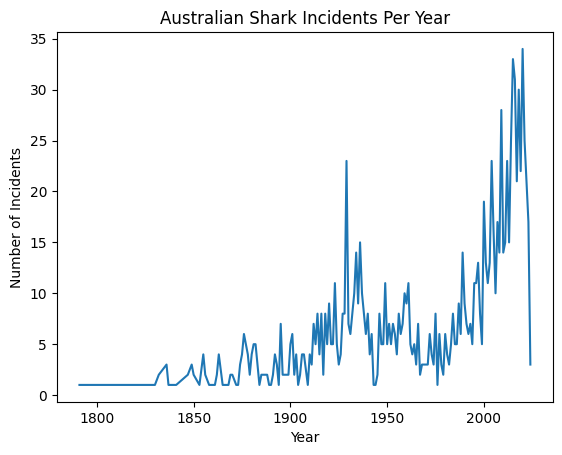

In [ ]:

yearly_incidents = df.groupby("Year").size()

plt.figure()
plt.plot(yearly_incidents.index, yearly_incidents.values)
plt.title("Australian Shark Incidents Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.show()


## 5. Monthly Seasonality of Incidents

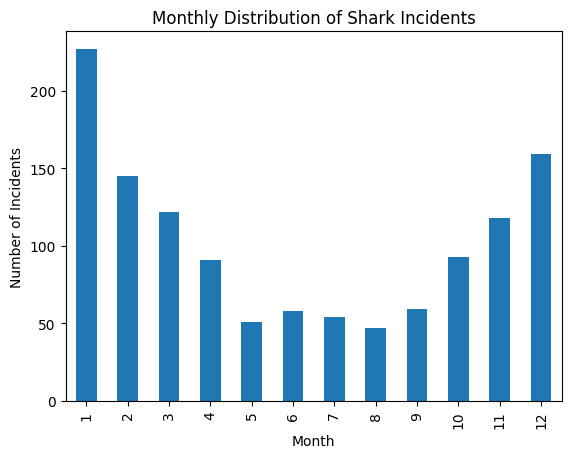

In [ ]:

monthly_incidents = df.groupby("Month").size()

plt.figure()
monthly_incidents.plot(kind="bar")
plt.title("Monthly Distribution of Shark Incidents")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.show()


## 6. Incident Type Distribution

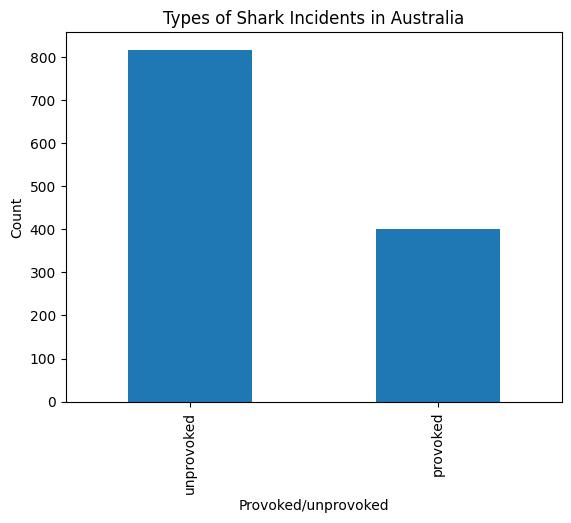

In [ ]:

df["Provoked/unprovoked"].value_counts().plot(kind="bar")
plt.title("Types of Shark Incidents in Australia")
plt.ylabel("Count")
plt.show()


## 7. Spatial Heatmap of Shark Incidents

In [ ]:

map_aus = folium.Map(location=[-25, 135], zoom_start=4)

heat_data = df[["Latitude", "Longitude"]].values.tolist()

HeatMap(heat_data, radius=8).add_to(map_aus)

map_aus


In [ ]:
df_us = pd.read_csv("/content/florida_shark_incidents.csv", encoding='latin1')

# Convert Latitude and Longitude to numeric, coercing errors to NaN
df_us['Latitude'] = pd.to_numeric(df_us['Latitude'], errors='coerce')
df_us['Longitude'] = pd.to_numeric(df_us['Longitude'], errors='coerce')

# Convert 'Incident.year' to numeric, handling errors, and then to Int64
df_us["Incident.year"] = pd.to_numeric(df_us["Incident.year"], errors="coerce")

# Drop rows with NaN in critical columns (Latitude, Longitude, Incident.year)
df_us = df_us.dropna(subset=["Latitude","Longitude", "Incident.year"]).copy()

# Create a 'Year' column from the cleaned 'Incident.year' column
df_us["Year"] = df_us["Incident.year"].astype("Int64")

df_us.head()

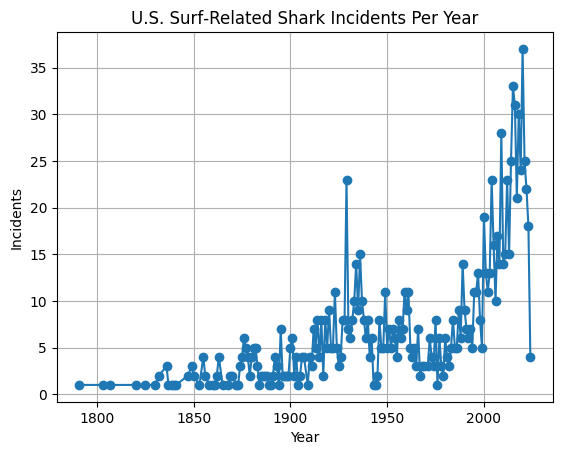

In [ ]:

us_yearly = df_us.groupby("Year").size()

plt.figure()
plt.plot(us_yearly.index, us_yearly.values, marker="o")
plt.title("U.S. Surf‑Related Shark Incidents Per Year")
plt.xlabel("Year")
plt.ylabel("Incidents")
plt.grid(True)
plt.show()


In [ ]:
map_us = folium.Map(location=[33, -95], zoom_start=4)
HeatMap(df_us[["Latitude","Longitude"]].values.tolist(), radius=9).add_to(map_us)
map_us

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
import streamlit.components.v1 as components
import matplotlib as mpl


# -----------------------------------------
# FONT + STYLE (MATCHES REFERENCE APP)
# -----------------------------------------
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 10

# -----------------------------------------
# PAGE CONFIG
# -----------------------------------------
st.set_page_config(
    page_title="Shark Activity Risk Dashboard",
    layout="wide"
)

# -----------------------------------------
# LOAD DATA
# -----------------------------------------
@st.cache_data
def load_aus():
    df = pd.read_excel(
        "Australian Shark-Incident Database Public Version.xlsx",
        engine="openpyxl"
    )
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Latitude","Longitude"])
    df["Year"] = df["Date"].dt.year
    df["Region"] = "Australia"
    return df

@st.cache_data
def load_us():
    df = pd.read_csv("us_coastal_shark_incidents.csv")
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Latitude","Longitude"])
    df["Region"] = "United States"
    return df

df_aus = load_aus()
df_us  = load_us()

df_all = pd.concat([df_aus, df_us], ignore_index=True)

# -----------------------------------------
# HEADER
# -----------------------------------------
st.title("🦈 Shark Activity Geospatial Risk Dashboard")
st.markdown(
    "A spatial decision-support tool for identifying **surf-zone shark activity hotspots**, "
    "temporal trends, and high-risk coastal locations across **Australia and the United States**."
)

# -----------------------------------------
# SIDEBAR — USER CONTROLS
# -----------------------------------------
st.sidebar.header("User Controls")

region_choice = st.sidebar.selectbox(
    "Select Region",
    ["Australia", "United States", "Both"]
)

year_range = st.sidebar.slider(
    "Year Range",
    int(df_all["Year"].min()),
    int(df_all["Year"].max()),
    (2018, 2023)
)

activity_filter = st.sidebar.multiselect(
    "Filter by Activity",
    sorted(df_all["Activity"].dropna().unique()),
    default=["Surfing"]
)

# -----------------------------------------
# APPLY FILTERS
# -----------------------------------------
df = df_all[
    (df_all["Year"] >= year_range[0]) &
    (df_all["Year"] <= year_range[1]) &
    (df_all["Activity"].isin(activity_filter))
]

if region_choice != "Both":
    df = df[df["Region"] == region_choice]

# -----------------------------------------
# METRICS
# -----------------------------------------
total_incidents = len(df)
recent_year = df["Year"].max()
recent_incidents = len(df[df["Year"] == recent_year])

top_location = (
    df["Location"].value_counts().idxmax()
    if "Location" in df.columns
    else df["Beach_Name"].value_counts().idxmax()
)

c1, c2, c3 = st.columns(3)
c1.metric("🦈 Total Recorded Incidents", total_incidents)
c2.metric(f"📅 Incidents in {recent_year}", recent_incidents)
c3.metric("🏖️ Top Incident Location", top_location)

# -----------------------------------------
# TABS
# -----------------------------------------
tab1, tab2, tab3 = st.tabs(
    ["📈 Temporal Trends", "🗺️ Spatial Heat Map", "🏖️ Hotspot Ranking"]
)

# -----------------------------------------
# TAB 1 — TEMPORAL TRENDS
# -----------------------------------------
with tab1:
    st.subheader("Incident Trends Over Time")

    yearly = df.groupby("Year").size()

    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(yearly.index, yearly.values, marker="o")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of Incidents")
    ax.grid(True)

    st.pyplot(fig)

# -----------------------------------------
# TAB 2 — SPATIAL MAP
# -----------------------------------------
with tab2:
    st.subheader("Shark Activity Hotspot Map")

    if region_choice == "Australia":
        m = folium.Map(location=[-25, 135], zoom_start=4)
    elif region_choice == "United States":
        m = folium.Map(location=[33, -95], zoom_start=4)
    else:
        m = folium.Map(location=[5, 120], zoom_start=3)

    heat_points = df[["Latitude","Longitude"]].values.tolist()

    HeatMap(
        heat_points,
        radius=12,
        blur=15
    ).add_to(m)

    components.html(m._repr_html_(), height=520)

# -----------------------------------------
# TAB 3 — HOTSPOT RANKING
# -----------------------------------------
with tab3:
    st.subheader("Ranked High-Risk Beaches")

    if "Beach_Name" in df.columns:
        ranking_col = "Beach_Name"
    else:
        ranking_col = "Location"

    ranking = (
        df[ranking_col]
        .value_counts()
        .rename("Incident_Count")
        .reset_index()
        .rename(columns={"index": "Location"})
    )

    st.dataframe(ranking, use_container_width=True)

# -----------------------------------------
# DOWNLOAD DATA
# -----------------------------------------
st.markdown("---")
st.download_button(
    "⬇️ Download Filtered Dataset (CSV)",
    df.to_csv(index=False),
    "shark_incident_filtered_export.csv",
    "text/csv"
)

st.caption("Data Sources: ASID • Florida / State incident records • Research dataset harmonisation")


Writing app.py


In [ ]:
!pip install streamlit pyngrok
!pip install streamlit_folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 523.7/523.7 kB 9.4 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("37hTy31WgryGiyth4rFYapiR0qb_R1aMuBpD43ZW5i9Ux9Vv")

In [ ]:
from pyngrok import ngrok

# Correct usage: pass integer port number
public_url = ngrok.connect(8501)
print("Streamlit app URL:", public_url)

# Start Streamlit app (blocking call)
!streamlit run /content/app.py

Streamlit app URL: NgrokTunnel: "https://terrilyn-futuristic-scripturally.ngrok-free.dev" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.68.7.109:8501

